In [1]:
import numpy as np
import pandas as pd

### Import Dataset

In [3]:
df = pd.read_csv('../../dataset/email spam/emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


### Check data

In [4]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [5]:
df.isna().sum()

text    0
spam    0
dtype: int64

### Visualize Data

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.stats import gaussian_kde


In [17]:
label_counts = df['spam'].value_counts()
label_percents = df['spam'].value_counts(normalize=True) * 100

In [12]:
plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid")

<Figure size 1000x1000 with 0 Axes>

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_47729/1418631678.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='spam', data=df, order=label_counts.index, palette='viridis')


Text(0, 0.5, 'Count')

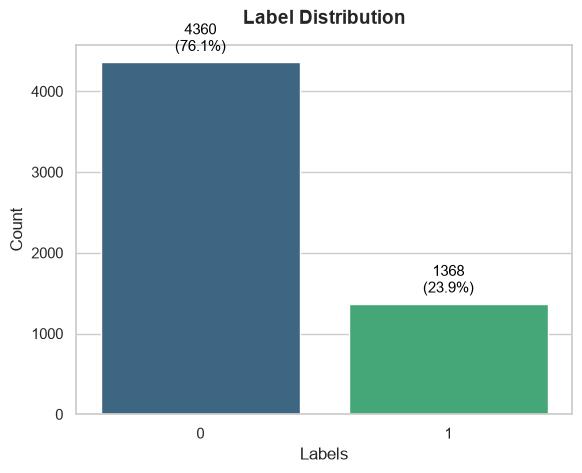

In [19]:
ax = sns.countplot(x='spam', data=df, order=label_counts.index, palette='viridis')
for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df)) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=11, color='black',
                xytext=(0, 5),
                textcoords='offset points')
plt.title('Label Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Count', fontsize=12)

In [21]:
df['msg length'] = df['text'].astype(str).apply(len)

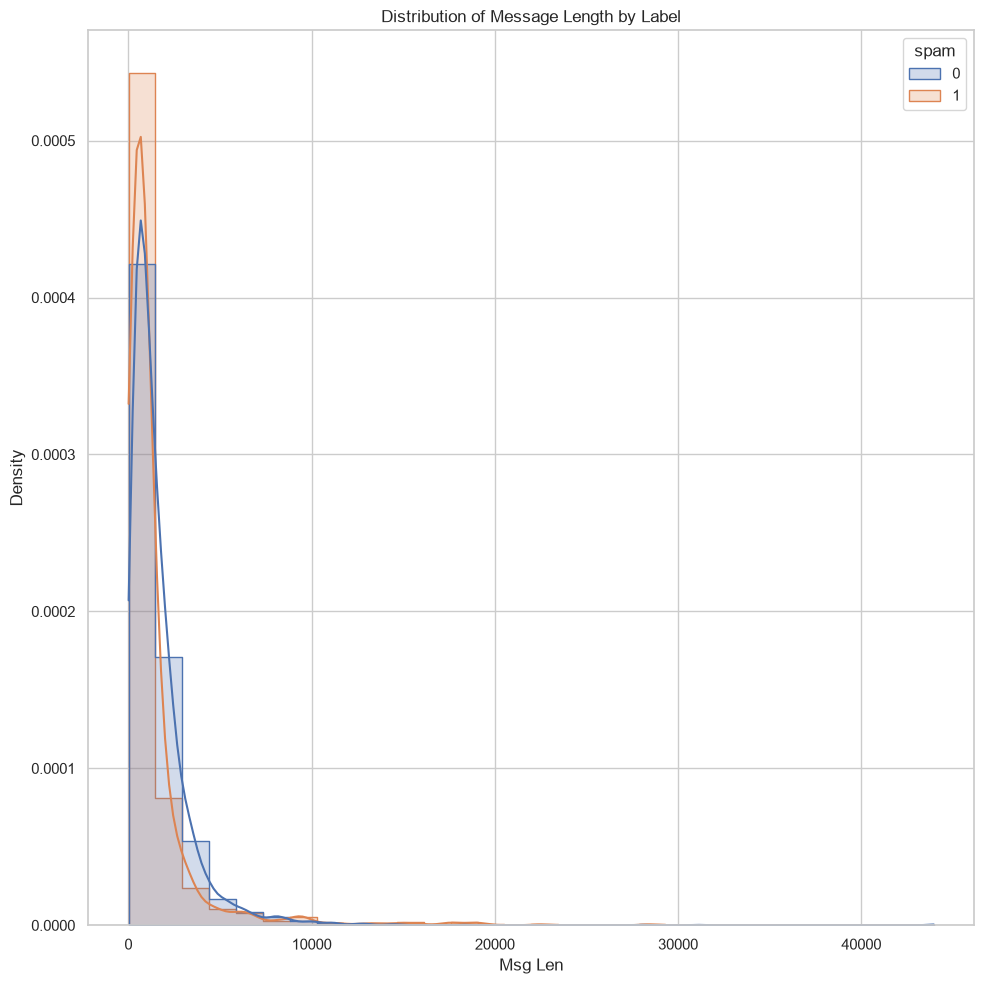

In [23]:
plt.figure(figsize=(10, 10))
sns.histplot(
    data=df,
    x='msg length',
    hue='spam',
    kde=True,
    bins=30,
    element="step",
    stat="density",
    common_norm=False)
plt.title('Distribution of Message Length by Label')
plt.xlabel('Msg Len')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### Processing Data

In [24]:
import math

In [25]:
df = df.drop(['msg length'], axis=1)

In [26]:
X = df['text']
y = df['spam']

In [27]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    words = text.split()
    return words

In [29]:
def build_vocab(messages):
    vocab = set()
    for msg in messages:
        words = preprocess_text(msg)
        for word in words:
            vocab.add(word)
    return sorted(vocab)

In [32]:
vocab = build_vocab(df['text'])
print(f"Total len: {len(vocab)}")

Total len: 37339


In [33]:
# Compute TF - IDF
def calculate_tf(words):

    word_count = {}

    for word in words:
        word_count[word] = word_count.get(word, 0) + 1

    total_words = len(words)

    tf = {}

    for word, count in word_count.items():
        tf[word] = count / total_words

    return tf

In [34]:
def calculate_idf(messages, vocab):

    N = len(messages)

    document_frequency = {
        word: 0
        for word in vocab
    }

    for message in messages:

        words = set(preprocess_text(message))

        for word in words:

            if word in document_frequency:
                document_frequency[word] += 1

    idf = {}

    for word in vocab:

        df_word = document_frequency[word]

        idf[word] = math.log(N / df_word)

    return idf

In [35]:
idf = calculate_idf(df['text'], vocab)

In [36]:
def tfidf_vectorize(messages, vocabulary, idf):

    vectors = []

    for message in messages:

        words = preprocess_text(message)

        tf = calculate_tf(words)

        vector = []

        for word in vocabulary:

            tf_value = tf.get(word, 0)

            tfidf_value = tf_value * idf[word]

            vector.append(tfidf_value)

        vectors.append(vector)

    return vectors

In [38]:
X_tfidf = tfidf_vectorize(df['text'], vocab, idf)

In [39]:
X_tfidf = np.array(X_tfidf)
print(f"The shape of X_tfidf = {X_tfidf.shape}")

The shape of X_tfidf = (5728, 37339)


### Slip Data

In [40]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Training Data

In [44]:
import sys
import os

root_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if root_path not in sys.path:
    sys.path.append(root_path)

from clazz.LogisticRegression import LogisticRegression

In [45]:
logistic = LogisticRegression()

In [46]:
logistic.fit(X_train, y_train)

### Predict Data

In [49]:
y_pred = logistic.predict(X_train)
y_pred_test = logistic.predict(X_test)

### Evaluation Prediction

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      3488
           1       1.00      0.15      0.25      1094

    accuracy                           0.80      4582
   macro avg       0.89      0.57      0.57      4582
weighted avg       0.84      0.80      0.73      4582



In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       872
           1       1.00      0.12      0.22       274

    accuracy                           0.79      1146
   macro avg       0.89      0.56      0.55      1146
weighted avg       0.84      0.79      0.72      1146

